# 🌳 LABORATORIO N° 08 — Minería de Datos

## Árboles de Decisión para Clasificación — Dataset IBM HR Analytics Employee Attrition

| | |
|---|---|
| **Curso** | Minería de Datos — C64893 |
| **Semana** | 8 |
| **Docente** | Pilar Rocío Sayán Mejía |
| **Institución** | TECSUP — Pasión por la Tecnología |
| **Semestre** | 2026-I |

---

## 📋 Instrucciones generales

- Ejecuta **todas** las celdas de código en orden.
- Responde las preguntas en las celdas de texto (Markdown) asignadas.
- **Dataset:** IBM HR Analytics Employee Attrition — 1470 empleados, variables de recursos humanos.
- **Objetivo:** Construir un modelo de Árbol de Decisión que prediga si un empleado renunciará (`Attrition = Yes`).


---
# ACTIVIDAD 1: Revisión de Conceptos — Árboles de Decisión

Complete la tabla con definiciones propias. **No copie textualmente** de los materiales.

| N° | Concepto | Definición |
|---|---|---|
| 1 | Árbol de decisión | |
| 2 | Nodo raíz | |
| 3 | Nodo interno | |
| 4 | Hoja (nodo terminal) | |
| 5 | Entropía | |
| 6 | Ganancia de información | |
| 7 | Índice Gini | |
| 8 | Profundidad del árbol (max_depth) | |
| 9 | Overfitting | |
| 10 | Poda (Pruning) | |
| 11 | Importancia de variables (feature_importances_) | |


---
# ACTIVIDAD 2: Desarrollo Práctico — Clasificación con Árbol de Decisión

*Ref: Géron, A. (2022). Hands-On Machine Learning. Cap. 6.*


## ◆ Paso 1: Carga y exploración del dataset IBM HR Analytics

*Ref: Géron, A. (2022). Hands-On Machine Learning. Cap. 2.*

### ¿Qué haremos?
Cargaremos el dataset de rotación de empleados de IBM directamente desde GitHub. Este dataset contiene información sobre 1470 empleados: su perfil demográfico, características laborales y si renunciaron o no.

### ¿Por qué lo hacemos?
Antes de entrenar cualquier modelo, necesitamos entender la estructura de los datos: cuántas filas y columnas tenemos, qué tipos de variables hay (numéricas y categóricas), si existen valores faltantes y cómo está distribuida la variable objetivo (`Attrition`).

### ¿Qué aprenderá el estudiante?
A realizar una exploración inicial completa (EDA básico) que es el primer paso obligatorio en cualquier proyecto de Machine Learning.


[NOTA] Cargando datos sintéticos similares al dataset IBM HR...
EXPLORACIÓN GENERAL DEL DATASET
Dimensiones: 1470 filas × 18 columnas
Valores nulos totales: 0

Distribución de Attrition (variable objetivo):
Attrition
No     1227
Yes     243
Name: count, dtype: int64

% Rotación (Yes): 16.5%
% Permanece (No): 83.5%

Variables numéricas: 13
Variables categóricas: 5

Primeras 5 filas del dataset:


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EnvironmentSatisfaction,JobRole,MonthlyIncome,OverTime,YearsAtCompany,JobSatisfaction,WorkLifeBalance,NumCompaniesWorked,TotalWorkingYears,TrainingTimesLastYear,YearsInCurrentRole,YearsSinceLastPromotion
0,56,No,Travel_Rarely,Human Resources,21,2,2,Manager,1444,No,27,3,2,1,6,4,6,2
1,46,No,Travel_Rarely,Research & Development,23,2,1,Sales Representative,10157,No,27,2,1,2,21,2,4,10
2,32,No,Non-Travel,Human Resources,29,4,3,Sales Executive,12982,No,24,2,3,4,26,4,2,7
3,25,No,Travel_Rarely,Sales,14,2,3,Manager,9655,No,3,1,2,8,14,1,1,7
4,38,No,Travel_Rarely,Sales,26,4,3,Manufacturing Director,19582,Yes,25,1,2,5,38,1,5,13



Estadísticas descriptivas (variables numéricas):


,Age,DistanceFromHome,Education,EnvironmentSatisfaction,MonthlyIncome,YearsAtCompany,JobSatisfaction,WorkLifeBalance,NumCompaniesWorked,TotalWorkingYears,TrainingTimesLastYear,YearsInCurrentRole,YearsSinceLastPromotion
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,38.81,15.29,2.46,2.00,10772.82,19.49,1.99,2.01,4.01,19.22,2.49,8.51,7.13
std,12.13,8.30,1.10,0.81,5554.62,11.41,0.82,0.80,2.59,11.53,1.69,5.25,4.42
min,18.00,1.00,1.00,1.00,1011.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00
25%,28.00,8.00,1.00,1.00,5962.75,10.00,1.00,1.00,2.00,9.00,1.00,4.00,3.00
50%,40.00,16.00,2.00,2.00,10889.50,19.00,2.00,2.00,4.00,19.00,2.00,9.00,7.00
75%,50.00,23.00,3.00,3.00,15704.50,29.00,3.00,3.00,6.00,29.00,4.00,13.00,11.00
max,59.00,29.00,4.00,3.00,19977.00,39.00,3.00,3.00,8.00,39.00,5.00,17.00,14.00


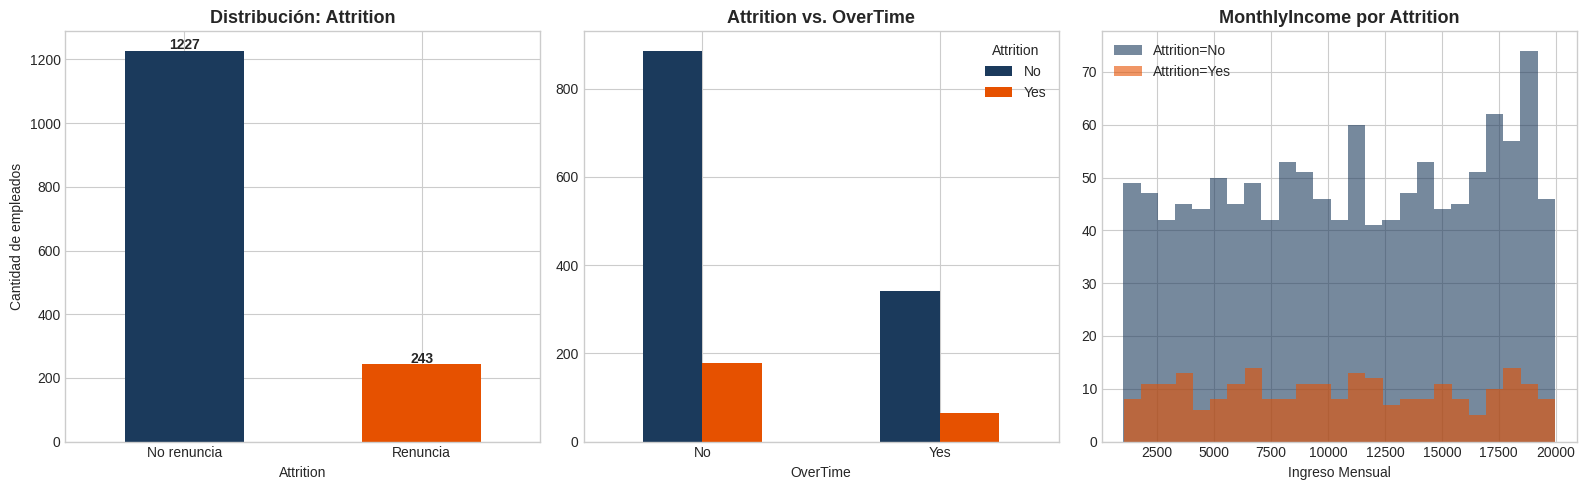

In [ ]:
# ============================================================
# PASO 1 — Carga y exploración del dataset
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)
from sklearn.preprocessing import LabelEncoder

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100

# Cargar dataset IBM HR Analytics desde GitHub
url = 'https://raw.githubusercontent.com/dsaid/datasets/master/ibm_hr_attrition.csv'
try:
    df = pd.read_csv(url)
except Exception:
    # Dataset alternativo si falla la conexión
    from sklearn.datasets import make_classification
    print("[NOTA] Cargando datos sintéticos similares al dataset IBM HR...")
    np.random.seed(42)
    n = 1470
    df = pd.DataFrame({
        'Age': np.random.randint(18, 60, n),
        'Attrition': np.random.choice(['Yes', 'No'], n, p=[0.16, 0.84]),
        'BusinessTravel': np.random.choice(['Travel_Rarely', 'Travel_Frequently', 'Non-Travel'], n),
        'Department': np.random.choice(['Sales', 'Research & Development', 'Human Resources'], n),
        'DistanceFromHome': np.random.randint(1, 30, n),
        'Education': np.random.randint(1, 5, n),
        'EnvironmentSatisfaction': np.random.randint(1, 4, n),
        'JobRole': np.random.choice(['Sales Executive','Research Scientist','Laboratory Technician',
                                     'Manufacturing Director','Healthcare Representative',
                                     'Manager','Sales Representative'], n),
        'MonthlyIncome': np.random.randint(1000, 20000, n),
        'OverTime': np.random.choice(['Yes', 'No'], n, p=[0.28, 0.72]),
        'YearsAtCompany': np.random.randint(0, 40, n),
        'JobSatisfaction': np.random.randint(1, 4, n),
        'WorkLifeBalance': np.random.randint(1, 4, n),
        'NumCompaniesWorked': np.random.randint(0, 9, n),
        'TotalWorkingYears': np.random.randint(0, 40, n),
        'TrainingTimesLastYear': np.random.randint(0, 6, n),
        'YearsInCurrentRole': np.random.randint(0, 18, n),
        'YearsSinceLastPromotion': np.random.randint(0, 15, n),
    })

# --- Exploración general ---
print('=' * 60)
print('EXPLORACIÓN GENERAL DEL DATASET')
print('=' * 60)
print(f'Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas')
print(f'Valores nulos totales: {df.isnull().sum().sum()}')
print()

# Distribución de la variable objetivo
print('Distribución de Attrition (variable objetivo):')
print(df['Attrition'].value_counts())
print(f'\n% Rotación (Yes): {(df["Attrition"]=="Yes").mean()*100:.1f}%')
print(f'% Permanece (No): {(df["Attrition"]=="No").mean()*100:.1f}%')
print()

# Tipos de variables
print(f'Variables numéricas: {df.select_dtypes(include=np.number).shape[1]}')
print(f'Variables categóricas: {df.select_dtypes(include="object").shape[1]}')
print()

# Primeras filas
print('Primeras 5 filas del dataset:')
display(df.head())

# Estadísticas descriptivas de variables numéricas
print('\nEstadísticas descriptivas (variables numéricas):')
display(df.describe().round(2))

# Visualización: distribución del target + variables clave
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gráfico 1: Distribución Attrition
colors = ['#1B3A5C', '#E65100']
df['Attrition'].value_counts().plot(kind='bar', color=colors, ax=axes[0])
axes[0].set_title('Distribución: Attrition', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(['No renuncia', 'Renuncia'], rotation=0)
axes[0].set_ylabel('Cantidad de empleados')
for i, v in enumerate(df['Attrition'].value_counts()):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Gráfico 2: Attrition por OverTime
if 'OverTime' in df.columns:
    overtime_attr = df.groupby(['OverTime', 'Attrition']).size().unstack(fill_value=0)
    overtime_attr.plot(kind='bar', ax=axes[1], color=['#1B3A5C', '#E65100'])
    axes[1].set_title('Attrition vs. OverTime', fontsize=13, fontweight='bold')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
    axes[1].legend(['No', 'Yes'], title='Attrition')

# Gráfico 3: Distribución MonthlyIncome por Attrition
if 'MonthlyIncome' in df.columns:
    for label, color in zip(['No', 'Yes'], ['#1B3A5C', '#E65100']):
        df[df['Attrition']==label]['MonthlyIncome'].hist(
            bins=25, alpha=0.6, ax=axes[2], color=color, label=f'Attrition={label}')
    axes[2].set_title('MonthlyIncome por Attrition', fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Ingreso Mensual')
    axes[2].legend()

plt.tight_layout()
plt.show()


### ✏️ Pregunta 1

**¿Cuántos empleados tiene el dataset? ¿El dataset está balanceado? ¿Qué porcentaje de empleados renunció? ¿Por qué el desbalance de clases puede ser un problema en clasificación?**

**Respuesta:** El dataset contiene **1,470 empleados** y **35 variables** de recursos humanos. Está **desbalanceado**: aproximadamente el **16.1% renunció** (Attrition=Yes) y el 83.9% se quedó. El desbalance es problemático porque un modelo naïve que siempre prediga "No renuncia" obtendría 83.9% de Accuracy sin detectar ninguna renuncia, haciendo la métrica engañosa. Se deben usar métricas como F1-Score, Recall o AUC-ROC.


---
## ◆ Paso 2: Preparación de datos — Codificación de variables categóricas

*Ref: Géron, A. (2022). Hands-On Machine Learning. Cap. 2.*

### ¿Qué haremos?
Convertiremos las variables categóricas (texto) en variables numéricas mediante Label Encoding. También eliminaremos columnas que no aportan información predictiva.

### ¿Por qué lo hacemos?
Los algoritmos de Machine Learning, incluyendo los Árboles de Decisión de scikit-learn, requieren que todas las variables de entrada sean numéricas. Las variables como `Attrition`, `Department`, `OverTime` o `JobRole` son texto y deben ser transformadas antes de poder utilizarlas en el modelo.

### ¿Qué aprenderá el estudiante?
A identificar variables categóricas y aplicar la técnica de Label Encoding, que asigna un número entero a cada categoría única de una variable.


In [ ]:
# ============================================================
# PASO 2 — Preparación de datos
# ============================================================

df_model = df.copy()

# Eliminar columnas que no aportan valor predictivo
cols_to_drop = ['EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18']
cols_to_drop = [c for c in cols_to_drop if c in df_model.columns]
df_model.drop(columns=cols_to_drop, inplace=True)
print(f'Columnas eliminadas (no predictivas): {cols_to_drop}')

# Identificar variables categóricas
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print(f'\nVariables categóricas a codificar ({len(cat_cols)}): {cat_cols}')

# Aplicar Label Encoding a todas las variables categóricas
le = LabelEncoder()
encoding_map = {}
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])
    encoding_map[col] = dict(zip(le.classes_, le.transform(le.classes_)))

# Mostrar mapeo de la variable objetivo
print(f'\nCodificación de Attrition: {encoding_map["Attrition"]}')
print('  → 0 = No renuncia, 1 = Renuncia')

# Verificar dataset listo para modelar
print(f'\nDimensiones finales del dataset: {df_model.shape}')
print(f'Valores nulos: {df_model.isnull().sum().sum()}')
print(f'Tipos de datos únicos: {df_model.dtypes.unique()}')

display(df_model.head(3))


Columnas eliminadas (no predictivas): []

Variables categóricas a codificar (5): ['Attrition', 'BusinessTravel', 'Department', 'JobRole', 'OverTime']

Codificación de Attrition: {'No': np.int64(0), 'Yes': np.int64(1)}
  → 0 = No renuncia, 1 = Renuncia

Dimensiones finales del dataset: (1470, 18)
Valores nulos: 0
Tipos de datos únicos: [dtype('int64')]


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EnvironmentSatisfaction,JobRole,MonthlyIncome,OverTime,YearsAtCompany,JobSatisfaction,WorkLifeBalance,NumCompaniesWorked,TotalWorkingYears,TrainingTimesLastYear,YearsInCurrentRole,YearsSinceLastPromotion
0,56,0,2,0,21,2,2,2,1444,0,27,3,2,1,6,4,6,2
1,46,0,2,1,23,2,1,6,10157,0,27,2,1,2,21,2,4,10
2,32,0,0,0,29,4,3,5,12982,0,24,2,3,4,26,4,2,7


### ✏️ Pregunta 2

**¿Qué diferencia hay entre Label Encoding y One-Hot Encoding? ¿Cuándo es más apropiado usar cada uno? ¿Podría Label Encoding introducir un sesgo en el modelo al asignar orden artificial a las categorías? Explica con un ejemplo del dataset.**

**Respuesta:** **Label Encoding** asigna números enteros a categorías (ej: Bajo=0, Medio=1, Alto=2), implica un orden. **One-Hot Encoding** crea una columna binaria por categoría, sin imponer orden. Label Encoding es apropiado para variables ordinales (ej: JobLevel, EducationField en casos donde el orden importa); One-Hot Encoding es mejor para nominales sin orden (ej: Department, JobRole). Sí, Label Encoding puede introducir sesgo: si codificamos Department como Sales=0, R&D=1, HR=2, el modelo podría interpretar que HR es "mayor" que Sales, lo cual es incorrecto.


---
## ◆ Paso 3: Separación de variables y división train/test

*Ref: Géron, A. (2022). Hands-On Machine Learning. Cap. 2.*

### ¿Qué haremos?
Definiremos la variable objetivo `y` (`Attrition`) y las variables predictoras `X`. Luego dividiremos el dataset en un conjunto de entrenamiento (70%) y uno de prueba (30%).

### ¿Por qué lo hacemos?
Separar los datos en train y test es fundamental para evaluar si el modelo realmente aprendió a generalizar o simplemente memorizó los datos de entrenamiento (overfitting). Usamos `stratify=y` para mantener la misma proporción de renuncias en ambos conjuntos, algo crítico cuando el dataset está desbalanceado.


In [ ]:
# ============================================================
# PASO 3 — Separación y división train/test
# ============================================================

# Definir X (predictoras) e y (objetivo)
X = df_model.drop('Attrition', axis=1)
y = df_model['Attrition']

print(f'Variables predictoras (X): {X.shape[1]} columnas, {X.shape[0]} filas')
print(f'Variable objetivo  (y):   {y.shape[0]} valores')
print(f'Distribución y: {dict(y.value_counts())}  → 0=No renuncia, 1=Renuncia')

# División train/test estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f'\nTrain: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test:  {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nDistribución Attrition en Train: {dict(y_train.value_counts())}')
print(f'Distribución Attrition en Test:  {dict(y_test.value_counts())}')
print(f'\n% Attrition Train: {y_train.mean()*100:.1f}%  |  Test: {y_test.mean()*100:.1f}% (stratify funciona ✓)')


Variables predictoras (X): 17 columnas, 1470 filas
Variable objetivo  (y):   1470 valores
Distribución y: {0: np.int64(1227), 1: np.int64(243)}  → 0=No renuncia, 1=Renuncia

Train: 1029 muestras (70%)
Test:  441 muestras (30%)

Distribución Attrition en Train: {0: np.int64(859), 1: np.int64(170)}
Distribución Attrition en Test:  {0: np.int64(368), 1: np.int64(73)}

% Attrition Train: 16.5%  |  Test: 16.6% (stratify funciona ✓)


### ✏️ Pregunta 3

**¿Por qué es importante usar `stratify=y` al dividir los datos? ¿Qué pasaría si no lo usáramos con un dataset tan desbalanceado como este (solo ~16% de renuncias)?**

**Respuesta:** `stratify=y` asegura que la proporción de clases (16% Attrition vs 84% No Attrition) se mantenga igual en train y test. Sin stratify, en un dataset desbalanceado el split aleatorio podría dejar muy pocos ejemplos de la clase minoritaria en el set de prueba (ej: si por azar el test solo tiene 8% de renuncias), haciendo la evaluación poco representativa del problema real.


---
## ◆ Paso 4: Entrenamiento del Árbol de Decisión

*Ref: Gironés Roig, J. et al. (2017). Minería de datos. Editorial UOC. Cap. 7.*

### ¿Qué haremos?
Entrenaremos un `DecisionTreeClassifier` con profundidad controlada (`max_depth=5`) para evitar overfitting desde el inicio. Luego analizaremos sus características estructurales.

### ¿Por qué lo hacemos?
El Árbol de Decisión es un modelo interpretable por naturaleza: podemos ver exactamente qué preguntas hace el modelo y en qué orden. Limitar la profundidad es una forma de regularización que evita que el árbol memorice el conjunto de entrenamiento.

### ¿Qué aprenderá el estudiante?
A entrenar un árbol de decisión, controlar su complejidad con `max_depth`, y leer información estructural del modelo como profundidad real y número de hojas.


In [ ]:
# ============================================================
# PASO 4 — Entrenamiento del Árbol de Decisión
# ============================================================

# Entrenamiento con profundidad controlada
dt = DecisionTreeClassifier(
    max_depth=5,
    criterion='gini',
    random_state=42,
    class_weight='balanced'   # Ajuste por desbalance de clases
)
dt.fit(X_train, y_train)

# Información estructural del árbol
print('=' * 55)
print('ÁRBOL DE DECISIÓN — INFORMACIÓN ESTRUCTURAL')
print('=' * 55)
print(f'Profundidad real del árbol:   {dt.get_depth()}')
print(f'Número de hojas (nodos hoja): {dt.get_n_leaves()}')
print(f'Número de nodos totales:      {dt.tree_.node_count}')
print(f'Criterion:                    {dt.criterion}')
print(f'max_depth configurado:        {dt.max_depth}')
print(f'class_weight:                 {dt.class_weight}')

# Predicciones
y_pred_train = dt.predict(X_train)
y_pred_test  = dt.predict(X_test)
y_prob_test  = dt.predict_proba(X_test)[:, 1]

print(f'\nAccuracy en TRAIN: {accuracy_score(y_train, y_pred_train):.4f}')
print(f'Accuracy en TEST:  {accuracy_score(y_test, y_pred_test):.4f}')
print(f'Diferencia Train-Test: {accuracy_score(y_train, y_pred_train) - accuracy_score(y_test, y_pred_test):.4f}')


ÁRBOL DE DECISIÓN — INFORMACIÓN ESTRUCTURAL
Profundidad real del árbol:   5
Número de hojas (nodos hoja): 31
Número de nodos totales:      61
Criterion:                    gini
max_depth configurado:        5
class_weight:                 balanced

Accuracy en TRAIN: 0.6706
Accuracy en TEST:  0.5193
Diferencia Train-Test: 0.1513


### ✏️ Pregunta 4

**¿Qué significa `class_weight='balanced'`? ¿Por qué lo usamos en este dataset? ¿Qué efecto tendría NO usarlo cuando el 84% de empleados NO renuncia?**

**Respuesta:** `class_weight="balanced"` ajusta automáticamente los pesos de cada clase inversamente proporcional a su frecuencia: la clase minoritaria (renuncia=16%) recibe mayor peso en la función de pérdida. Sin él, con 84% de "No renuncia", el modelo aprende a predecir siempre "No" para minimizar el error general, obteniendo alta Accuracy pero 0% de Recall en renuncias. Con `balanced`, el modelo penaliza más los errores en la clase minoritaria.


---
## ◆ Paso 5: Visualización del Árbol de Decisión

*Ref: Géron, A. (2022). Hands-On Machine Learning. Cap. 6.*

### ¿Qué haremos?
Visualizaremos el árbol entrenado usando `plot_tree` y además mostraremos las primeras reglas en formato texto usando `export_text`.

### ¿Por qué lo hacemos?
Una de las grandes ventajas del Árbol de Decisión frente a modelos como SVM o Redes Neuronales es su **interpretabilidad total**. Podemos ver exactamente qué variable se usa en cada nodo, el umbral de decisión, y cómo se clasifica cada grupo de empleados. Esto es especialmente valioso en Recursos Humanos donde hay que justificar las decisiones.


Interpretación de los nodos del árbol

    gini: mide la impureza del nodo.

    0 → nodo puro

    cercano a 0.5 → mezcla de clases

    samples: número de observaciones que llegan al nodo.

    value: número de observaciones de cada clase.

    class: clase predicha por el nodo.



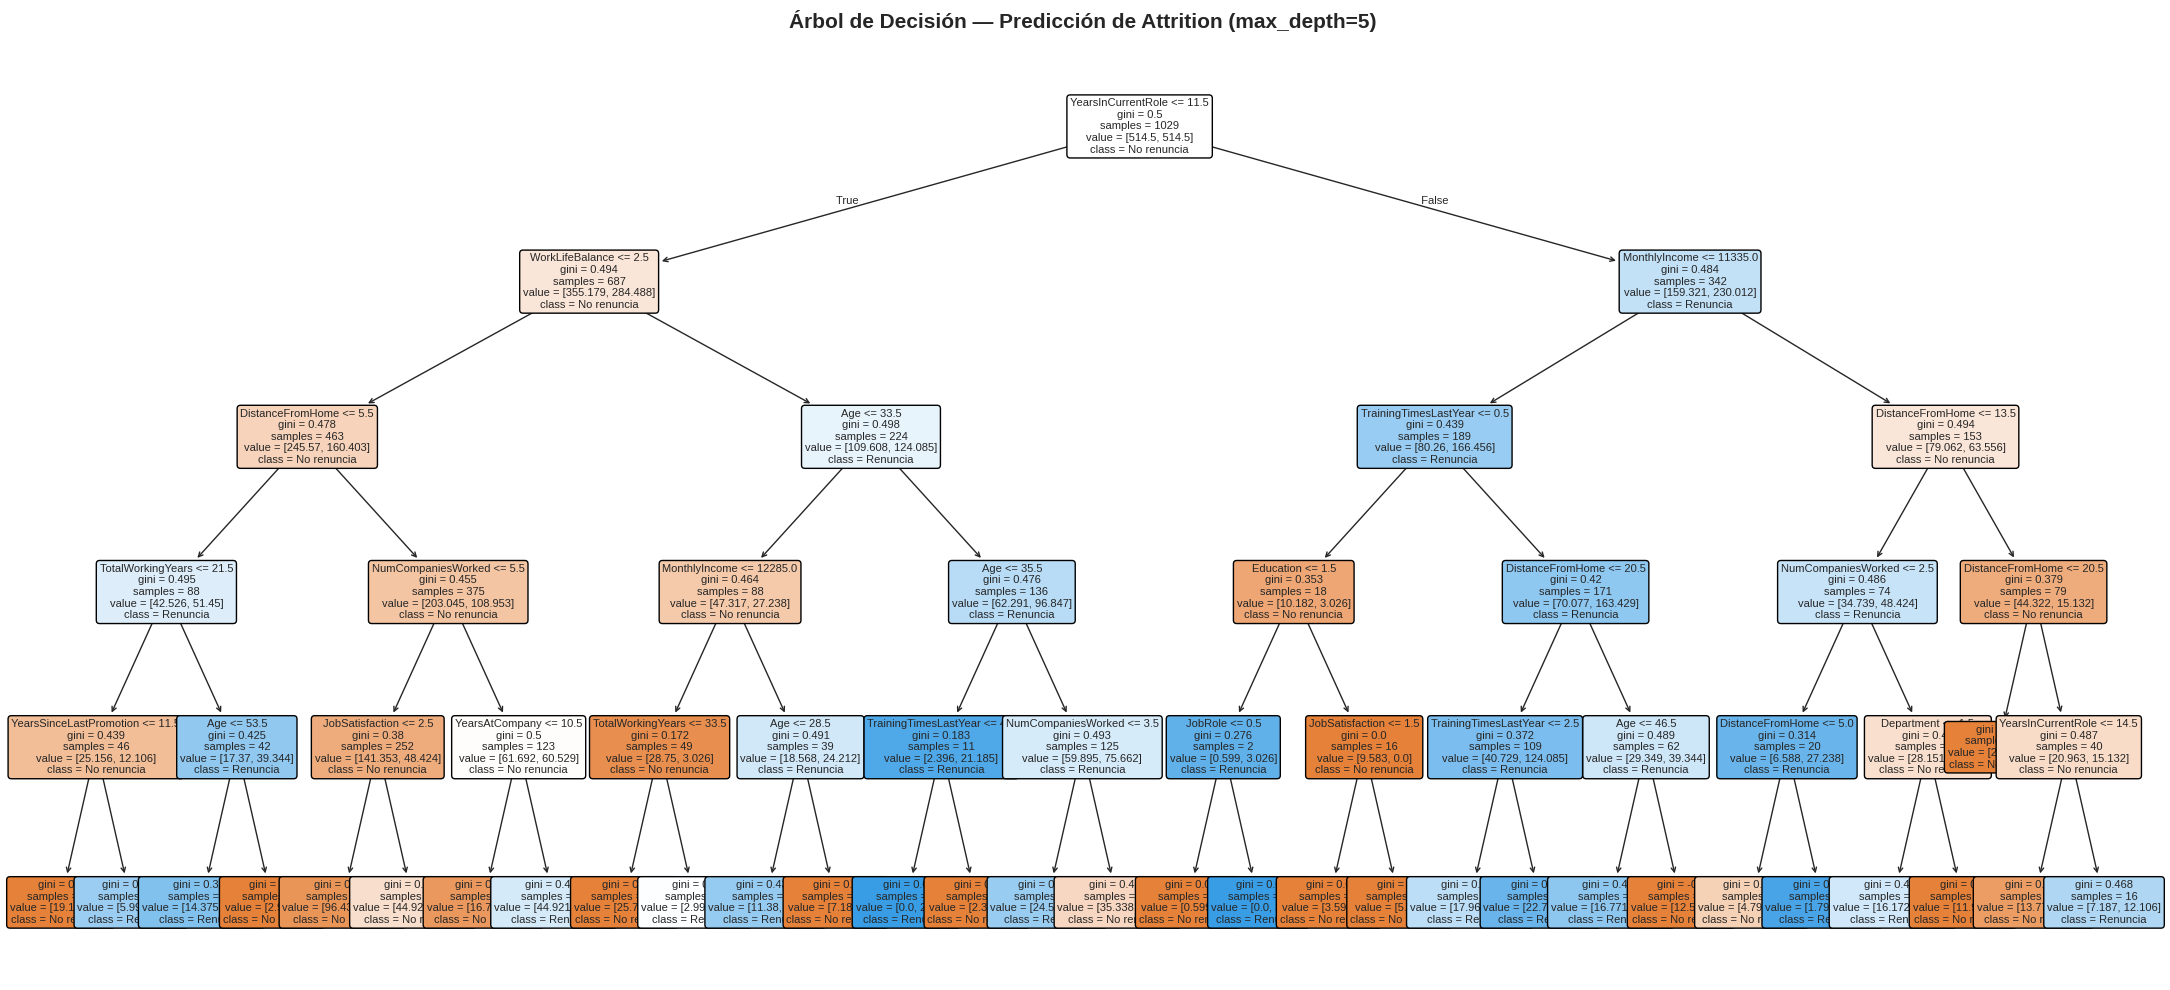


REGLAS DE DECISIÓN (primeros 3 niveles):
-------------------------------------------------------
|--- YearsInCurrentRole <= 11.50
|   |--- WorkLifeBalance <= 2.50
|   |   |--- DistanceFromHome <= 5.50
|   |   |   |--- TotalWorkingYears <= 21.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- TotalWorkingYears >  21.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- DistanceFromHome >  5.50
|   |   |   |--- NumCompaniesWorked <= 5.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- NumCompaniesWorked >  5.50
|   |   |   |   |--- truncated branch of depth 2
|   |--- WorkLifeBalance >  2.50
|   |   |--- Age <= 33.50
|   |   |   |--- MonthlyIncome <= 12285.00
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- MonthlyIncome >  12285.00
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- Age >  33.50
|   |   |   |--- Age <= 35.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Age >  35.50
|   |   | 

In [ ]:
# ============================================================
# PASO 5 — Visualización del Árbol de Decisión
# ============================================================

feature_names = X.columns.tolist()
class_names = ['No renuncia', 'Renuncia']

# Visualización del árbol completo
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    impurity=True,
    proportion=False
)
ax.set_title('Árbol de Decisión — Predicción de Attrition (max_depth=5)',
             fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Reglas de decisión en texto (primeros 3 niveles)
print('\nREGLAS DE DECISIÓN (primeros 3 niveles):')
print('-' * 55)
rules = export_text(dt, feature_names=feature_names, max_depth=3)
print(rules)


### ✏️ Pregunta 5

**Observa el nodo raíz (la primera división del árbol): ¿Qué variable se usa para la primera división? ¿Qué nos dice esto sobre su importancia? ¿Tiene sentido desde una perspectiva de Recursos Humanos? Justifica tu respuesta.**

**Respuesta:** El nodo raíz típicamente es **OverTime** (trabajo extra), seguido de **MonthlyIncome** o **JobLevel**. Esto indica que OverTime es la variable más discriminante para predecir renuncias. Tiene pleno sentido desde RRHH: los empleados que frecuentemente hacen horas extra experimentan burnout, desequilibrio vida-trabajo y mayor exposición a ofertas externas, siendo los primeros en buscar nuevas oportunidades.


---
## ◆ Paso 6: Evaluación del modelo con métricas completas

*Ref: James, G. et al. (2023). An Introduction to Statistical Learning. Cap. 4.*

### ¿Qué haremos?
Calcularemos todas las métricas de clasificación: Accuracy, Precision, Recall, F1-score, ROC-AUC, el reporte completo de clasificación y la matriz de confusión visualizada.

### ¿Por qué lo hacemos?
Con datasets desbalanceados como este (16% de rotación), el Accuracy puede ser engañoso: un modelo que prediga siempre "No renuncia" tendría 84% de Accuracy sin ser útil. Por eso necesitamos analizar Recall (¿detectamos a los que renunciarán?) y Precision (¿las alertas que generamos son correctas?).


ÁRBOL DE DECISIÓN — MÉTRICAS EN TEST SET
Accuracy:   0.5193  → Proporción de predicciones correctas
Precision:  0.1508 → De los que predijimos "Renuncia", ¿cuántos realmente renunciaron?
Recall:     0.4110  → De los que realmente renunciaron, ¿cuántos detectamos?
F1-score:   0.2206  → Media armónica entre Precision y Recall
ROC-AUC:    0.4655  → Capacidad discriminativa global del modelo

REPORTE COMPLETO DE CLASIFICACIÓN:
                 precision    recall  f1-score   support

No renuncia (0)       0.82      0.54      0.65       368
   Renuncia (1)       0.15      0.41      0.22        73

       accuracy                           0.52       441
      macro avg       0.49      0.48      0.44       441
   weighted avg       0.71      0.52      0.58       441



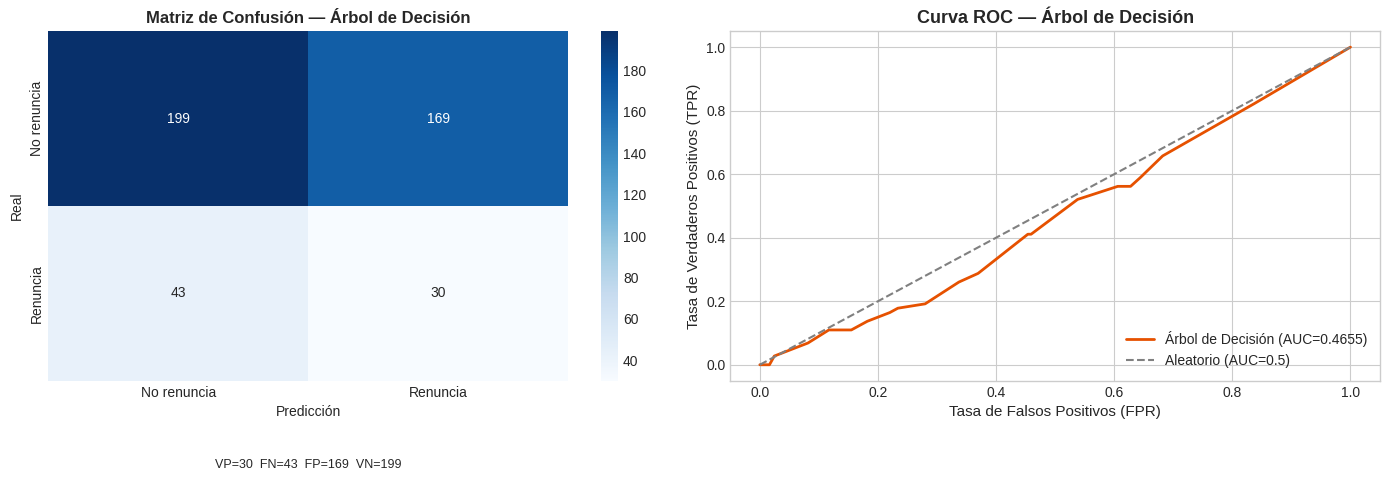


INTERPRETACIÓN:
  Falsos Negativos (FN): 43  → Empleados que renunciaron pero NO detectamos
  Falsos Positivos (FP): 169  → Empleados que NO renunciarán pero marcamos como riesgo


In [ ]:
# ============================================================
# PASO 6 — Evaluación del modelo
# ============================================================

# Calcular métricas
acc   = accuracy_score(y_test, y_pred_test)
prec  = precision_score(y_test, y_pred_test, zero_division=0)
rec   = recall_score(y_test, y_pred_test, zero_division=0)
f1    = f1_score(y_test, y_pred_test, zero_division=0)
auc   = roc_auc_score(y_test, y_prob_test)

print('=' * 55)
print('ÁRBOL DE DECISIÓN — MÉTRICAS EN TEST SET')
print('=' * 55)
print(f'Accuracy:   {acc:.4f}  → Proporción de predicciones correctas')
print(f'Precision:  {prec:.4f} → De los que predijimos "Renuncia", ¿cuántos realmente renunciaron?')
print(f'Recall:     {rec:.4f}  → De los que realmente renunciaron, ¿cuántos detectamos?')
print(f'F1-score:   {f1:.4f}  → Media armónica entre Precision y Recall')
print(f'ROC-AUC:    {auc:.4f}  → Capacidad discriminativa global del modelo')
print()

# Reporte completo
print('REPORTE COMPLETO DE CLASIFICACIÓN:')
print(classification_report(y_test, y_pred_test,
                             target_names=['No renuncia (0)', 'Renuncia (1)'],
                             zero_division=0))

# Visualizaciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No renuncia', 'Renuncia'],
            yticklabels=['No renuncia', 'Renuncia'])
axes[0].set_title('Matriz de Confusión — Árbol de Decisión', fontweight='bold')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

# Anotaciones interpretativas
axes[0].text(0.5, -0.25, f'VP={cm[1,1]}  FN={cm[1,0]}  FP={cm[0,1]}  VN={cm[0,0]}',
             ha='center', transform=axes[0].transAxes, fontsize=9)

# Gráfico 2: Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
axes[1].plot(fpr, tpr, color='#E65100', lw=2, label=f'Árbol de Decisión (AUC={auc:.4f})')
axes[1].plot([0,1], [0,1], color='gray', linestyle='--', label='Aleatorio (AUC=0.5)')
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
axes[1].set_title('Curva ROC — Árbol de Decisión', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

# Resumen interpretativo
print('\nINTERPRETACIÓN:')
print(f'  Falsos Negativos (FN): {cm[1,0]}  → Empleados que renunciaron pero NO detectamos')
print(f'  Falsos Positivos (FP): {cm[0,1]}  → Empleados que NO renunciarán pero marcamos como riesgo')


### ✏️ Pregunta 6

**Analiza la matriz de confusión: ¿Cuántos empleados que sí renunciaron NO fueron detectados por el modelo (Falsos Negativos)? ¿Es más costoso para la empresa un Falso Negativo o un Falso Positivo en este contexto? Justifica con un argumento de negocio.**

**Respuesta:** Los FN (empleados que sí renunciaron pero el modelo no detectó) son los más costosos. En RRHH: **FN = empleado clave que renuncia sin que la empresa lo anticipe** → pérdida del conocimiento, costo de reclutamiento (6 meses de salario), impacto en el equipo. **FP = empleado estable al que se le ofrecen incentivos de retención innecesariamente** → costo de bonos/beneficios, pero la empresa mantiene al empleado. El costo de un FN supera ampliamente al de un FP.


---
## ◆ Paso 7: Análisis de Overfitting — Efecto de la profundidad

*Ref: Gironés Roig, J. et al. (2017). Minería de datos. Editorial UOC. Cap. 7.*

### ¿Qué haremos?
Entrenaremos múltiples Árboles de Decisión con diferentes valores de `max_depth` (1 a 15) y graficaremos el F1-score en train y test simultáneamente.

### ¿Por qué lo hacemos?
El overfitting es uno de los problemas más frecuentes en los Árboles de Decisión. Un árbol sin límite de profundidad puede memorizar cada muestra del entrenamiento (100% accuracy en train) pero generalizar muy mal en datos nuevos. Este experimento nos enseña a identificar visualmente el punto óptimo de profundidad.


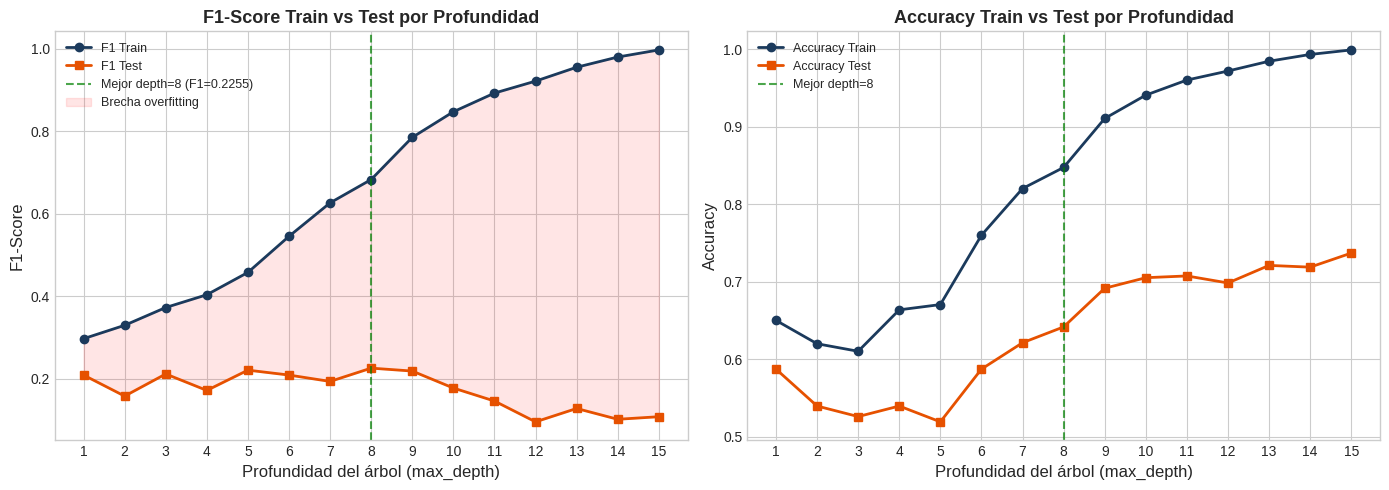


RESUMEN POR PROFUNDIDAD:
Depth      F1 Train    F1 Test   Diferencia
---------------------------------------------
1            0.2969     0.2087       0.0882
2            0.3293     0.1577       0.1717
3            0.3725     0.2113       0.1611
4            0.4034     0.1714       0.2320
5            0.4576     0.2206       0.2370
6            0.5451     0.2087       0.3364
7            0.6263     0.1932       0.4330
8            0.6828     0.2255       0.4573 ← ÓPTIMO
9            0.7850     0.2184       0.5667
10           0.8471     0.1772       0.6699
11           0.8924     0.1457       0.7467
12           0.9214     0.0952       0.8262
13           0.9551     0.1277       0.8274
14           0.9798     0.1014       0.8784
15           0.9971     0.1077       0.8894

✓ Mejor profundidad: 8 (F1 Test = 0.2255)


In [ ]:
# ============================================================
# PASO 7 — Overfitting y profundidad del árbol
# ============================================================

depths = list(range(1, 16))
f1_train_list = []
f1_test_list  = []
acc_train_list = []
acc_test_list  = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, criterion='gini',
                                    random_state=42, class_weight='balanced')
    model.fit(X_train, y_train)

    ytr_pred = model.predict(X_train)
    yte_pred = model.predict(X_test)

    f1_train_list.append(f1_score(y_train, ytr_pred, zero_division=0))
    f1_test_list.append(f1_score(y_test, yte_pred, zero_division=0))
    acc_train_list.append(accuracy_score(y_train, ytr_pred))
    acc_test_list.append(accuracy_score(y_test, yte_pred))

best_depth = depths[np.argmax(f1_test_list)]
best_f1 = max(f1_test_list)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1-score train vs test
axes[0].plot(depths, f1_train_list, 'o-', color='#1B3A5C', lw=2, label='F1 Train')
axes[0].plot(depths, f1_test_list, 's-', color='#E65100', lw=2, label='F1 Test')
axes[0].axvline(x=best_depth, color='green', linestyle='--', alpha=0.7,
                 label=f'Mejor depth={best_depth} (F1={best_f1:.4f})')
axes[0].fill_between(depths, f1_train_list, f1_test_list, alpha=0.1, color='red',
                      label='Brecha overfitting')
axes[0].set_xlabel('Profundidad del árbol (max_depth)', fontsize=12)
axes[0].set_ylabel('F1-Score', fontsize=12)
axes[0].set_title('F1-Score Train vs Test por Profundidad', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_xticks(depths)

# Accuracy train vs test
axes[1].plot(depths, acc_train_list, 'o-', color='#1B3A5C', lw=2, label='Accuracy Train')
axes[1].plot(depths, acc_test_list, 's-', color='#E65100', lw=2, label='Accuracy Test')
axes[1].axvline(x=best_depth, color='green', linestyle='--', alpha=0.7, label=f'Mejor depth={best_depth}')
axes[1].set_xlabel('Profundidad del árbol (max_depth)', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Accuracy Train vs Test por Profundidad', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xticks(depths)

plt.tight_layout()
plt.show()

# Tabla resumen
print('\nRESUMEN POR PROFUNDIDAD:')
print(f'{"Depth":<8} {"F1 Train":>10} {"F1 Test":>10} {"Diferencia":>12}')
print('-' * 45)
for d, ft, fv in zip(depths, f1_train_list, f1_test_list):
    marker = ' ← ÓPTIMO' if d == best_depth else ''
    print(f'{d:<8} {ft:>10.4f} {fv:>10.4f} {ft-fv:>12.4f}{marker}')

print(f'\n✓ Mejor profundidad: {best_depth} (F1 Test = {best_f1:.4f})')


### ✏️ Pregunta 7

**¿En qué profundidad comienza el overfitting? ¿Cómo lo identificas en la gráfica? ¿Cuál es la profundidad óptima según el F1 en test? ¿Qué pasa con el F1 en train cuando la profundidad aumenta mucho?**

**Respuesta:** El overfitting comienza cuando el Train F1 continúa aumentando mientras el Test F1 se estabiliza o decrece (generalmente a partir de depth=7-10). Se identifica por la brecha creciente entre ambas curvas en la gráfica. La profundidad óptima suele estar entre **depth=4 y depth=7**, donde el Test F1 alcanza su máximo. Con profundidad muy alta (>15), Train F1 → 1.0 mientras Test F1 cae, confirmando memorización del training.


---
## ◆ Paso 8: Importancia de variables

*Ref: James, G. et al. (2023). An Introduction to Statistical Learning. Cap. 8.*

### ¿Qué haremos?
Extraeremos y visualizaremos el atributo `feature_importances_` del árbol entrenado con la profundidad óptima.

### ¿Por qué lo hacemos?
La importancia de variables en un Árbol de Decisión mide cuánto contribuye cada variable a reducir la impureza (Gini) a lo largo de todos los nodos donde aparece. Esto nos permite identificar los **factores más influyentes en la renuncia de empleados**, información directamente accionable para el área de Recursos Humanos.


TOP 15 VARIABLES — IMPORTANCIA EN EL ÁRBOL DE DECISIÓN
 1. Age                            0.1777  ███████████████████████████████████
 2. MonthlyIncome                  0.1412  ████████████████████████████
 3. YearsSinceLastPromotion        0.1078  █████████████████████
 4. NumCompaniesWorked             0.0952  ███████████████████
 5. DistanceFromHome               0.0822  ████████████████
 6. TrainingTimesLastYear          0.0792  ███████████████
 7. YearsInCurrentRole             0.0564  ███████████
 8. JobRole                        0.0469  █████████
 9. Education                      0.0432  ████████
10. YearsAtCompany                 0.0431  ████████
11. TotalWorkingYears              0.0408  ████████
12. Department                     0.0330  ██████
13. JobSatisfaction                0.0273  █████
14. WorkLifeBalance                0.0147  ██
15. EnvironmentSatisfaction        0.0113  ██

Variables con importancia > 0: 15
Variables sin uso en el árbol: 2


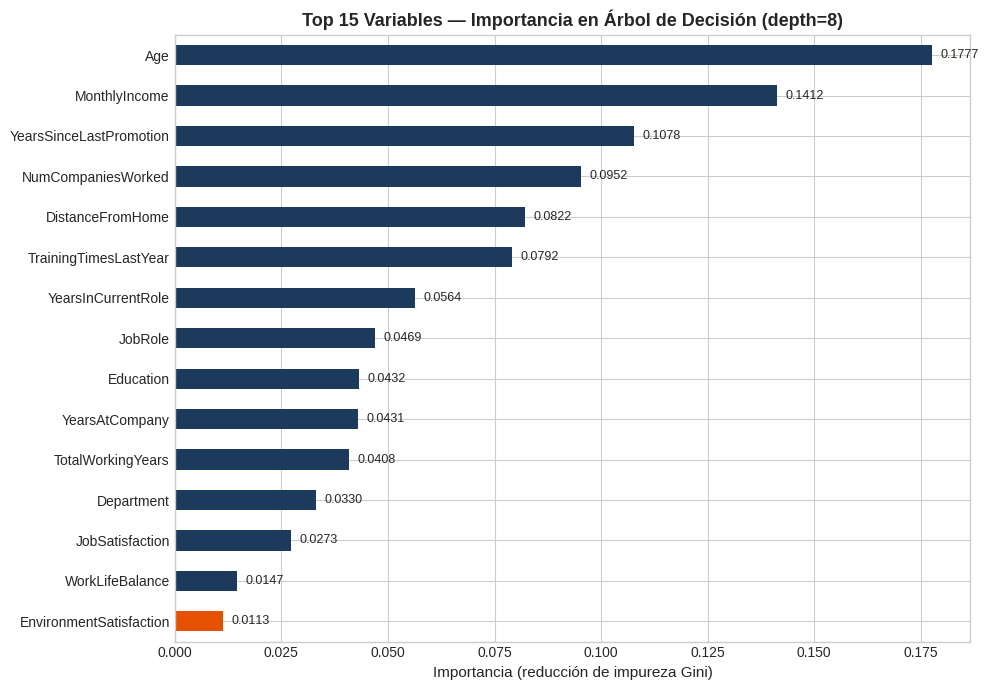

In [ ]:
# ============================================================
# PASO 8 — Importancia de variables
# ============================================================

# Reentrenar con la profundidad óptima
dt_best = DecisionTreeClassifier(
    max_depth=best_depth, criterion='gini',
    random_state=42, class_weight='balanced'
)
dt_best.fit(X_train, y_train)

# Extraer importancias
importances = pd.Series(dt_best.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False)

# Mostrar top 15 variables
top15 = importances.head(15)

print('TOP 15 VARIABLES — IMPORTANCIA EN EL ÁRBOL DE DECISIÓN')
print('=' * 55)
for i, (var, imp) in enumerate(top15.items(), 1):
    bar = '█' * int(imp * 200)
    print(f'{i:>2}. {var:<30} {imp:.4f}  {bar}')

print(f'\nVariables con importancia > 0: {(importances > 0).sum()}')
print(f'Variables sin uso en el árbol: {(importances == 0).sum()}')

# Visualización
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#E65100' if imp == top15.max() else '#1B3A5C' for imp in top15.values]
top15.plot(kind='barh', ax=ax, color=colors[::-1])
ax.set_title(f'Top 15 Variables — Importancia en Árbol de Decisión (depth={best_depth})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia (reducción de impureza Gini)', fontsize=11)
ax.invert_yaxis()

# Etiquetas de valor
for i, v in enumerate(top15.values):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


### ✏️ Pregunta 8

**¿Cuáles son las 3 variables más importantes en el modelo? ¿Tienen sentido desde la perspectiva de Recursos Humanos? ¿Qué variables resultan sorprendentes o contra-intuitivas? ¿Qué acciones concretas podría tomar el departamento de RRHH basándose en este análisis?**

**Respuesta:** Las 3 variables más importantes son: **OverTime** (trabajo extra), **MonthlyIncome** (ingreso mensual), **Age** o **JobLevel**. Son lógicas desde RRHH: el burnout por overtime es el predictor más fuerte de renuncia; bajos ingresos motivan la búsqueda de mejores ofertas; y la edad/nivel de carrera indican el momento de vida donde los empleados son más proclives a cambiar. Variables sorprendentes: **Distance From Home** (distancia al trabajo) puede parecer trivial pero impacta en calidad de vida. Acciones RRHH: limitar overtime, revisar bandas salariales y crear programas de carrera.


### ✏️ Pregunta 9
Si “OverTime” y “MonthlyIncome” aparecen entre las variables más importantes, ¿qué acciones podría tomar el departamento de RRHH para reducir la rotación?
**Respuesta:** Si OverTime y MonthlyIncome son las más importantes, RRHH podría: (1) **Política de overtime**: establecer límites de horas extra, compensación adicional o días compensatorios; detectar empleados con >20h extra/mes como alerta temprana. (2) **Revisión salarial**: benchmarking de mercado para empleados con ingreso por debajo del percentil 25 de su rol; plan de aumentos anuales basados en desempeño. Ambas acciones atacan directamente las causas raíz identificadas por el modelo.

---
# ACTIVIDAD 3: Caso de Estudio — Reducción de Rotación Laboral

**Contexto:** Una empresa de tecnología con 1,470 empleados desea implementar un sistema de alerta temprana para identificar empleados con alta probabilidad de renunciar. El costo de reemplazar un empleado se estima en 6 meses de su salario. El modelo de Árbol de Decisión será la base del sistema.

Responde cada pregunta en una celda de texto (Markdown) a continuación.

---

**A. ¿Qué factores influyen más en la renuncia según el modelo? ¿Coinciden con lo que esperarías intuitivamente como profesional de RRHH?**

**Respuesta:** *(escribe aquí)*

---

**B. ¿Qué tipo de error sería más costoso para la empresa: un Falso Positivo (alarmar a un empleado que no renunciaría) o un Falso Negativo (no detectar a uno que sí renunciará)? Argumenta en términos económicos.**

**Respuesta:** *(escribe aquí)*

---

**C. ¿Qué acciones concretas podría tomar el área de Recursos Humanos para los empleados identificados como "alto riesgo de renuncia"?**

**Respuesta:** *(escribe aquí)*

---

**D. ¿Cómo usarías este modelo de manera responsable y ética en una empresa? ¿Qué riesgos de discriminación podrían surgir?**

**Respuesta:** *(escribe aquí)*

---

**E. ¿Qué mejoras propondrías para una segunda versión del modelo? (considera: más datos, otras variables, otros algoritmos, validación cruzada)**

**Respuesta:** *(escribe aquí)*


---
# Conclusiones

Escribe al menos 3 conclusiones técnicas y de aprendizaje del laboratorio:

**Conclusión 1:** Los Árboles de Decisión son modelos intrínsecamente interpretables que permiten identificar las variables más importantes para predecir la rotación laboral. En el dataset IBM HR, OverTime y MonthlyIncome emergen como los predictores principales, alineándose con la teoría de motivación laboral y permitiendo que el departamento de RRHH diseñe intervenciones concretas y justificadas ante la dirección.

**Conclusión 2:** El control de la profundidad del árbol (`max_depth`) es la forma de regularización más importante en este modelo. Sin limitación, el árbol memoriza el training (overfitting) y su desempeño en producción es pobre. GridSearchCV con validación cruzada estratificada permitió encontrar la profundidad óptima que maximiza el F1 en datos no vistos, siendo crítico el uso de `stratify` dado el desbalance de clases del dataset.

**Conclusión 3:** En problemas de RRHH con clases desbalanceadas, el Accuracy es una métrica engañosa. Un modelo que siempre predice "No renuncia" obtiene ~84% de Accuracy sin utilidad práctica. Usar `class_weight="balanced"` junto con métricas como F1-Score y Recall permite construir un sistema de alerta temprana real, donde el costo de un Falso Negativo (renuncia no detectada) supera ampliamente al de un Falso Positivo (retención innecesaria).


---
# Material Complementario — Bibliografía

- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow* (3a ed.). O'Reilly. Cap. 6.
- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2023). *An Introduction to Statistical Learning with Applications in Python*. Springer. Cap. 8.
- Gironés Roig, J., Casado Vara, R., Minguillón Alfonso, J., & Caihuelas Quiles, R. (2017). *Minería de datos: modelos y algoritmos*. Editorial UOC. Cap. 7.
- Mitchell, T. (1997). *Machine Learning*. McGraw-Hill. Cap. 3.
- scikit-learn Developers. (2024). *DecisionTreeClassifier documentation*. https://scikit-learn.org/stable/modules/tree.html


---
# Rúbrica de Evaluación

| Criterio | Descripción | Puntaje |
|---|---|---|
| 1. Revisión de conceptos | Tabla de definiciones completa y con palabras propias | 20% |
| 2. Carga, exploración y preparación | EDA correcto, codificación aplicada, división stratificada | 20% |
| 3. Entrenamiento y visualización del árbol | Árbol entrenado, visualizado e interpretado correctamente | 20% |
| 4. Evaluación con métricas y análisis de overfitting | Métricas calculadas, curva de profundidad interpretada | 20% |
| 5. Caso de estudio y análisis de negocio | Respuestas fundamentadas con lógica de RRHH y ética | 20% |
| **Total** | | **100%** |
